# RADI605 Final Project Notebook

**Title:** Prediction of Cardiovascular Disease in Patients with Type 2 Diabetes Mellitus  
**Course task:** Longitudinal sequence modelling with PyTorch

The central idea is to treat each patient's follow-up history as a short clinical sequence rather than as independent rows. This is appropriate because cardiovascular risk is not determined by a single visit alone; it develops across repeated measurements, comorbidities, and medication exposure over time.


## 1. Assignment interpretation and assumptions

Before training any model, I fixed the problem setting so the rest of the notebook would be consistent and reproducible.

1. I treat `time_step` as the longitudinal order of follow-up for each patient.
2. I use a **5-step sequence** for every patient because the assignment explicitly asks for five time steps.
3. If a patient has fewer than 5 observations, I pad the remaining steps; if a patient has more than 5 observations, I keep the earliest 5 records.
4. I use `CVD` as the prediction target and remove it from the input features to avoid target leakage.
5. I split the data at the **patient level**, not the row level, so the same patient cannot appear in more than one subset.
6. I handle missing data in two stages: within-patient forward/backward filling first, then training-set statistics for any values that are still missing.
7. I use a simple RNN as the baseline and a bidirectional GRU as the improved model.

These assumptions are stated clearly here because they affect every later step, especially preprocessing, sequence construction, and model evaluation.

In [1]:


import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## 0. Configuration

This section defines the basic experimental environment. The purpose is to make the analysis reproducible and easy to rerun on another machine or in a private GitHub repository.


The next cell defines the file paths, random seeds, hardware setting, and the fixed sequence length used throughout the project.

I kept these settings at the top for two reasons. First, they make the notebook easier to reproduce. Second, they make it easier to check that the same configuration was used for both the baseline and the improved model. In particular, `MAX_STEPS = 5` is important because it directly enforces the project requirement of using a fixed five-step longitudinal input.

In [2]:

DATA_PATH = Path("D:\\Mahidol\\Modern ML\\final\\HEJUN WANG - dmcvd_data.csv")  # change this in your own repo
OUTPUT_DIR = Path("./output")
MODEL_DIR = Path("./model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
MAX_STEPS = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

## 1. Load data

The raw dataset is first loaded in its original long format, where each row corresponds to one patient visit or yearly step. Before any modelling starts, it is important to verify that the file is read correctly and that date fields are parsed as dates rather than plain text.


The next cell loads the raw CSV file and reports the overall shape of the dataset together with the number of unique patients.

I use this first inspection to confirm that the data are longitudinal rather than purely cross-sectional. It also gives the basic cohort size that I refer to later when I describe sequence construction and the train/validation/test split.

In [3]:
# =========================
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "dob", "dead_date"], low_memory=False)
print("Raw shape:", df.shape)
print("Unique patients:", df["ENC_HN"].nunique())

Raw shape: (56635, 58)
Unique patients: 7021


## 2. Problem definition and modelling assumptions

Before selecting features or building models, the prediction target must be defined carefully. In clinical machine learning, weak problem definition often leads to leakage, ambiguous evaluation, or claims that are difficult to defend.


In this project, I formulate the task as **patient-level CVD detection from a fixed 5-step observation window**. For each patient, I build one sequence from the first five yearly records and assign one patient-level label based on the CVD information observed within that window.

I chose this formulation for three main reasons:

1. It matches the assignment requirement of using five time steps.
2. It preserves the temporal order of repeated follow-up measurements.
3. It avoids using information beyond the defined observation window.

This is therefore a sequence classification problem, not a row-by-row classification problem.

## 3. Feature engineering

Feature engineering converts raw clinical variables into model-ready inputs while keeping the design clinically meaningful. The goal here is not to use every available column blindly, but to select variables that plausibly relate to cardiovascular risk in patients with type 2 diabetes mellitus.


The next cell creates derived variables and defines the final feature set used for modelling.

My main feature-engineering decisions are straightforward:

- I convert `dob` and `visit_date` into **age**, because age is clinically interpretable while raw date strings are not.
- I encode **sex** numerically so it can be used by the model.
- I remove patient identifiers and obvious leakage variables from the predictor list.
- I keep predictors that are clinically reasonable for cardiovascular risk in diabetes, including demographics, body size, blood pressure, diabetic complications, medication exposure, lipid markers, glucose control, and renal function.

I did not try to keep every available column. Instead, I kept variables that I could justify clinically and that were usable within a reproducible preprocessing pipeline.

In [4]:

df["age"] = ((df["visit_date"] - df["dob"]).dt.days / 365.25).astype(float)
df["sex_num"] = df["sex"].map({"F": 0.0, "M": 1.0})

feature_cols = [
    "age", "sex_num",
    "weight", "height", "DBP", "SBP",
    "hypertension", "dyslipidemia", "DR", "DN", "PVD",
    "alpha glucosidase inhibitors", "biguanides", "dpp4", "glp1", "insulin",
    "meglitinides", "sglt2", "sulfonylureas", "thiazolidinediones",
    "ace inhibitor", "alpha-adrenoreceptor antagonists",
    "angiotensin receptor blockers", "antiadrenergic agents, centrally acting",
    "beta blockers", "calcium channel blocker", "diuretics",
    "Ergot alkaloids", "hydrazinophthalazine derivatives",
    "pyrimidine derivatives", "rauwolfia alkaloids", "renin inhibitors",
    "fibric acid agents", "other lipid modifying agents", "statins",
    "CKMBMass", "Cholesterol", "Creatinine", "GlucoseNaF", "HCT",
    "HDLCholesterol", "HGB", "HbA1CEDTAblood", "LDLCholesterol",
    "Triglyceride", "eGFRCKDEPI",
]

binary_cols = [
    "sex_num",
    "hypertension", "dyslipidemia", "DR", "DN", "PVD",
    "alpha glucosidase inhibitors", "biguanides", "dpp4", "glp1", "insulin",
    "meglitinides", "sglt2", "sulfonylureas", "thiazolidinediones",
    "ace inhibitor", "alpha-adrenoreceptor antagonists",
    "angiotensin receptor blockers", "antiadrenergic agents, centrally acting",
    "beta blockers", "calcium channel blocker", "diuretics",
    "Ergot alkaloids", "hydrazinophthalazine derivatives",
    "pyrimidine derivatives", "rauwolfia alkaloids", "renin inhibitors",
    "fibric acid agents", "other lipid modifying agents", "statins",
]

numeric_cols = [c for c in feature_cols if c not in binary_cols]
id_cols = ["ENC_HN", "time_step", "visit_date", "CVD"]

work_df = df[id_cols + feature_cols].copy()
work_df = work_df.sort_values(["ENC_HN", "time_step"]).reset_index(drop=True)

## 4. Patient-level split

The dataset is split into training, validation, and test sets at the patient level. This is a critical methodological step in longitudinal healthcare modelling.


I split the dataset at the **patient level** rather than the row level. This is one of the most important design choices in the notebook.

If I had split rows directly, visits from the same patient could have appeared in both training and testing. That would leak patient-specific information across subsets and make the performance look better than it really is. To avoid that problem, I first identify unique patients, create a patient-level label, and then perform the split on patient IDs only.

The final proportions are **70% training, 15% validation, and 15% test**, which follow the assignment instructions. I also use stratification on the patient-level label so the class balance stays reasonably similar across the three subsets.

In [5]:
# =========================
patient_label = (
    work_df.groupby("ENC_HN")["CVD"]
    .max()
    .fillna(0)
    .astype(int)
)
patient_df = pd.DataFrame({"ENC_HN": patient_label.index, "label": patient_label.values})

train_ids, temp_ids = train_test_split(
    patient_df["ENC_HN"],
    test_size=0.30,
    random_state=SEED,
    stratify=patient_df["label"],
)

temp_df = patient_df[patient_df["ENC_HN"].isin(temp_ids)].copy()
val_ids, test_ids = train_test_split(
    temp_df["ENC_HN"],
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

train_ids = set(train_ids)
val_ids = set(val_ids)
test_ids = set(test_ids)

print(f"Train patients: {len(train_ids)} | Val patients: {len(val_ids)} | Test patients: {len(test_ids)}")

Train patients: 4914 | Val patients: 1053 | Test patients: 1054


## 5. Fit preprocessing statistics on the training set only

All preprocessing statistics must be learned from the training set only. This includes imputation values and standardization parameters.


The preprocessing strategy is intentionally conservative and easy to explain.

1. **Within-patient forward fill / backward fill for numeric variables**  
   For repeated measurements such as blood pressure, creatinine, HbA1c, and lipid values, the closest observations from the same patient are usually more sensible than borrowing information from the whole cohort immediately.

2. **Binary indicator imputation with zero**  
   For medication and diagnosis flags stored as 0/1 indicators, I treat missing values as absence unless the dataset explicitly says otherwise.

3. **Fallback to training-set medians**  
   If a numeric feature is still missing after within-patient filling, I replace it with the median from the training set. I use the median because many laboratory variables are skewed and may contain outliers.

4. **Standardization from training-set statistics**  
   I standardize the continuous features using the training-set mean and standard deviation, then apply the same transformation to validation and test data.

All preprocessing statistics are fitted on the training set only. This is necessary to keep the evaluation fair and to avoid leakage from validation or test data.

In [6]:
# =========================
train_rows = work_df[work_df["ENC_HN"].isin(train_ids)].copy()

# within-patient ffill / bfill for numeric columns (vectorized)
train_rows[numeric_cols] = train_rows.groupby("ENC_HN")[numeric_cols].ffill()
train_rows[numeric_cols] = train_rows.groupby("ENC_HN")[numeric_cols].bfill()

# binary indicators -> 0
train_rows[binary_cols] = train_rows[binary_cols].fillna(0)

train_medians = train_rows[numeric_cols].median()
train_means = train_rows[numeric_cols].fillna(train_medians).mean()
train_stds = train_rows[numeric_cols].fillna(train_medians).std().replace(0, 1.0)

preprocess_stats = {
    "medians": train_medians.to_dict(),
    "means": train_means.to_dict(),
    "stds": train_stds.to_dict(),
}

## 6. Build 5-step sequences

Once preprocessing statistics are available, the row-wise data are transformed into fixed-length patient sequences. This is the core step that converts the raw dataset into a sequence-learning problem.


After preprocessing, I convert the visit-level table into fixed-length patient sequences.

For each patient, I sort records by `time_step`, keep the first five observations, and pad shorter histories when needed. The sequence-building function returns three objects:

- **`X`**: the model input with shape `[N, 5, F]`
- **`y`**: the patient-level binary target
- **`seq_len`**: the true observed length before padding

I keep the true sequence length because the improved model uses packed sequences. That way, the recurrent layer pays attention to real observations rather than learning from padded rows.

In [7]:
# =========================
def transform_group_to_sequence(g: pd.DataFrame, max_steps: int = 5):
    g = g.iloc[:max_steps].copy()
    seq_len = len(g)

    # Imputation
    g[numeric_cols] = g[numeric_cols].ffill().bfill()
    for c in numeric_cols:
        g[c] = g[c].fillna(preprocess_stats["medians"][c])

    g[binary_cols] = g[binary_cols].fillna(0)

    # Standardize numeric features using training statistics
    for c in numeric_cols:
        g[c] = (g[c] - preprocess_stats["means"][c]) / preprocess_stats["stds"][c]

    g[binary_cols] = g[binary_cols].astype(float)

    y = int(g["CVD"].fillna(0).max())
    x = g[feature_cols].astype(np.float32).values

    if seq_len < max_steps:
        pad = np.zeros((max_steps - seq_len, len(feature_cols)), dtype=np.float32)
        x = np.vstack([x, pad])

    return x.astype(np.float32), y, seq_len


def build_dataset(raw_df: pd.DataFrame, patient_ids_set: set, max_steps: int = 5):
    subset = raw_df[raw_df["ENC_HN"].isin(patient_ids_set)].copy()

    X_list, y_list, len_list, pid_list = [], [], [], []
    for pid, g in subset.groupby("ENC_HN", sort=False):
        x, y, l = transform_group_to_sequence(g, max_steps=max_steps)
        X_list.append(x)
        y_list.append(y)
        len_list.append(l)
        pid_list.append(pid)

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.float32)
    lengths = np.array(len_list, dtype=np.int64)
    pids = np.array(pid_list)
    return X, y, lengths, pids


X_train, y_train, len_train, pid_train = build_dataset(work_df, train_ids, MAX_STEPS)
X_val, y_val, len_val, pid_val = build_dataset(work_df, val_ids, MAX_STEPS)
X_test, y_test, len_test, pid_test = build_dataset(work_df, test_ids, MAX_STEPS)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (4914, 5, 46) (4914,)
Val  : (1053, 5, 46) (1053,)
Test : (1054, 5, 46) (1054,)


## 7. Dataset and DataLoader

After sequence construction, the arrays are wrapped in a PyTorch dataset and data loaders. This creates the interface required for minibatch training.


The custom dataset stores three pieces of information for each patient: the fixed-length sequence, the binary label, and the observed sequence length.

The DataLoader then batches these samples for mini-batch training. This keeps memory use manageable and allows the same training loop to work for both the baseline model and the improved packed-sequence model.

In [8]:
# =========================
class SequenceDataset(Dataset):
    def __init__(self, X, y, lengths):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.lengths = torch.tensor(lengths, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx]


def make_loader(X, y, lengths, batch_size=32, shuffle=False):
    ds = SequenceDataset(X, y, lengths)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

## 8. Model definitions

Two recurrent models are implemented in this notebook: a baseline RNN and an improved bidirectional GRU. The comparison is designed to show not only whether performance changes, but also why architecture choices matter in longitudinal health data.


### Baseline model: vanilla RNN

I use a simple vanilla RNN as the baseline because it gives a clear reference point for the rest of the project. The baseline is not meant to be the strongest model; its role is to show what happens when the sequence is modelled with the most basic recurrent architecture.

### Improved model: bidirectional GRU with dropout and packed sequences

For the improved model, I replace the vanilla recurrent unit with a bidirectional GRU and keep dropout in the architecture. I also use packed sequences so padded timesteps have less influence on learning.

This change is reasonable for this task. A GRU has gating mechanisms that usually handle noisy longitudinal signals better than a plain RNN, and the bidirectional structure lets the model summarize the full five-step observation window before making the final classification.

In [9]:
# =========================
class BaselineRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            nonlinearity="tanh",
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.rnn(packed)
        last_hidden = hidden[-1]
        logits = self.fc(last_hidden).squeeze(1)
        return logits


class BiGRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        forward_last = hidden[-2]
        backward_last = hidden[-1]
        final_hidden = torch.cat([forward_last, backward_last], dim=1)
        final_hidden = self.dropout(final_hidden)
        logits = self.fc(final_hidden).squeeze(1)
        return logits

## 9. Evaluation metrics

A single accuracy value is not sufficient for evaluating a clinical risk model. For this reason, the notebook reports a group of complementary metrics.


The evaluation function reports several metrics: AUROC, AUPRC, accuracy, precision, recall, F1-score, specificity, and the confusion-matrix counts.

I treat **AUROC** and **AUPRC** as the most important summary metrics, especially AUPRC, because the positive class is relatively uncommon and accuracy alone would be misleading. I also keep recall and specificity because this is a clinical prediction task: missing higher-risk patients and over-flagging lower-risk patients are both important errors, so a single metric is not enough.

In [10]:
# =========================
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    all_probs, all_true = [], []
    for xb, yb, lb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        lb = lb.to(DEVICE)

        logits = model(xb, lb)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_true.extend(yb.detach().cpu().numpy().tolist())

    return np.array(all_true), np.array(all_probs)

## 10. Training utilities

This section defines the training loop, validation loop, probability prediction function, and the overall fitting routine used by both models.


The training utility is shared by both models so that the final comparison is as fair as possible.

A few implementation choices matter here:

- I use **`BCEWithLogitsLoss`** for numerically stable binary classification.
- I apply **positive-class weighting** to reduce the effect of class imbalance.
- I use **Adam** for optimization.
- I keep track of the best validation result and save the corresponding model weights.
- I store the training history so I can inspect whether learning is stable or obviously overfitted.

Using the same training framework for both models means that the main difference in performance should come from the model architecture rather than from inconsistent training settings.

In [11]:
# =========================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for xb, yb, lb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        lb = lb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb, lb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    for xb, yb, lb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        lb = lb.to(DEVICE)
        logits = model(xb, lb)
        loss = criterion(logits, yb)
        running_loss += loss.item() * xb.size(0)
    return running_loss / len(loader.dataset)


def fit_model(
    model,
    train_loader,
    val_loader,
    train_labels,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=50,
    patience=10,
    model_path="best_model.pt",
):
    pos_count = train_labels.sum()
    neg_count = len(train_labels) - pos_count
    pos_weight_value = neg_count / max(pos_count, 1.0)
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_score = -np.inf
    best_state = None
    history = {"train_loss": [], "val_loss": [], "val_auprc": [], "val_auroc": []}
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = evaluate_loss(model, val_loader, criterion)
        y_true_val, y_prob_val = predict_proba(model, val_loader)
        val_metrics = compute_metrics(y_true_val, y_prob_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auprc"].append(val_metrics["auprc"])
        history["val_auroc"].append(val_metrics["auroc"])

        score = val_metrics["auprc"]

        if score > best_score:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, model_path)
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(
            f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
            f"| val_auprc={val_metrics['auprc']:.4f} | val_auroc={val_metrics['auroc']:.4f}"
        )

        if bad_epochs >= patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def plot_training_history(history, title, save_path):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()


def plot_roc_pr(y_true, y_prob, prefix="model"):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {prefix}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"roc_{prefix}.png", dpi=200)
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {prefix}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"pr_{prefix}.png", dpi=200)
    plt.show()

## 11. Baseline model training

The baseline model is trained first so that it can serve as the reference model for the rest of the project.


The baseline-training cell saves the model weights, produces the learning curves, and reports the final test metrics.

These results matter because they define the reference point for the project. If the improved model cannot do better than this baseline on the same split and under the same preprocessing pipeline, then the architectural change would not be convincing.

Epoch 001 | train_loss=1.0818 | val_loss=0.9581 | val_auprc=0.3536 | val_auroc=0.8182
Epoch 002 | train_loss=1.0005 | val_loss=0.9532 | val_auprc=0.3737 | val_auroc=0.8167
Epoch 003 | train_loss=0.9702 | val_loss=0.9578 | val_auprc=0.3799 | val_auroc=0.8149
Epoch 004 | train_loss=0.9499 | val_loss=0.9778 | val_auprc=0.3771 | val_auroc=0.8047
Epoch 005 | train_loss=0.9325 | val_loss=1.0252 | val_auprc=0.3529 | val_auroc=0.7831
Epoch 006 | train_loss=0.9131 | val_loss=1.0093 | val_auprc=0.3711 | val_auroc=0.7938
Epoch 007 | train_loss=0.8977 | val_loss=1.0330 | val_auprc=0.3645 | val_auroc=0.7807
Epoch 008 | train_loss=0.8816 | val_loss=1.0121 | val_auprc=0.3860 | val_auroc=0.7935
Epoch 009 | train_loss=0.8617 | val_loss=1.0497 | val_auprc=0.3767 | val_auroc=0.7849
Epoch 010 | train_loss=0.8566 | val_loss=1.0369 | val_auprc=0.3844 | val_auroc=0.7986
Epoch 011 | train_loss=0.8266 | val_loss=1.0837 | val_auprc=0.3613 | val_auroc=0.7811
Epoch 012 | train_loss=0.8153 | val_loss=1.0662 | val_

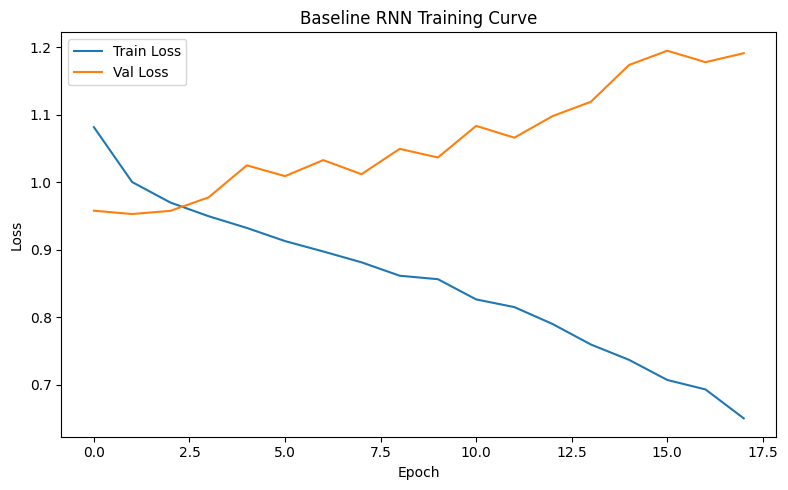

Baseline RNN test metrics: {
  "auroc": 0.7656289308176103,
  "auprc": 0.29789455185491726,
  "accuracy": 0.7428842504743833,
  "precision": 0.2140468227424749,
  "recall": 0.64,
  "f1": 0.3208020050125313,
  "specificity": 0.7536687631027253,
  "tn": 719,
  "fp": 235,
  "fn": 36,
  "tp": 64
}


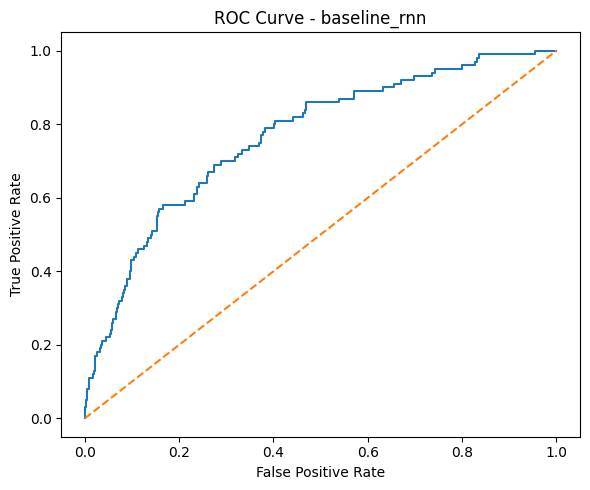

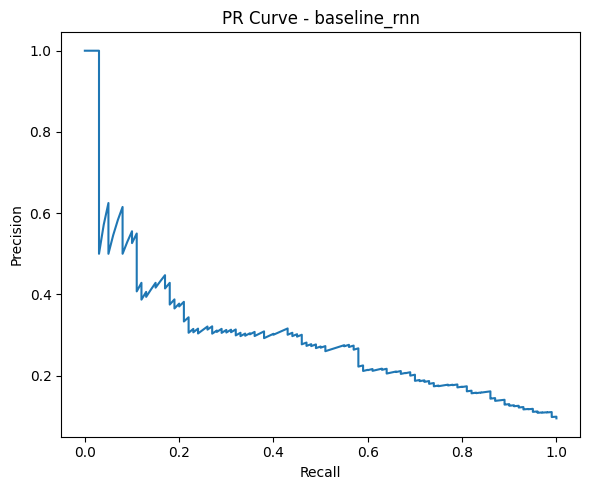

In [12]:
baseline_batch_size = 32
train_loader = make_loader(X_train, y_train, len_train, batch_size=baseline_batch_size, shuffle=True)
val_loader = make_loader(X_val, y_val, len_val, batch_size=baseline_batch_size, shuffle=False)
test_loader = make_loader(X_test, y_test, len_test, batch_size=baseline_batch_size, shuffle=False)

baseline_model = BaselineRNN(
    input_dim=len(feature_cols),
    hidden_dim=64,
    num_layers=1,
    dropout=0.0,
).to(DEVICE)

baseline_model, baseline_history = fit_model(
    baseline_model,
    train_loader,
    val_loader,
    train_labels=y_train,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=50,
    patience=10,
    model_path=MODEL_DIR / "best_rnn.pt",
)

plot_training_history(
    baseline_history,
    title="Baseline RNN Training Curve",
    save_path=OUTPUT_DIR / "training_curve_rnn.png",
)

y_true_test_rnn, y_prob_test_rnn = predict_proba(baseline_model, test_loader)
baseline_metrics = compute_metrics(y_true_test_rnn, y_prob_test_rnn)
print("Baseline RNN test metrics:", json.dumps(baseline_metrics, indent=2))
plot_roc_pr(y_true_test_rnn, y_prob_test_rnn, prefix="baseline_rnn")

## 12. Hyperparameter tuning for the improved model

A small hyperparameter search is carried out for the improved model using the validation set. The aim is not to exhaust every possible configuration, but to demonstrate a structured model-selection process.


For the improved model, I tune the main hyperparameters that are most likely to affect performance: hidden size, number of recurrent layers, dropout, learning rate, batch size, and weight decay.

I rank candidate models primarily by **validation AUPRC** and then by **validation AUROC**. I chose this ranking because the positive class is clinically important and not evenly balanced with the negative class. After tuning, I retrain the final BiGRU using the selected configuration and evaluate it on the untouched test set.

In [13]:
search_space = [
    {"hidden_dim": 32, "num_layers": 1, "dropout": 0.2, "lr": 1e-3, "batch_size": 32, "weight_decay": 1e-4},
    {"hidden_dim": 64, "num_layers": 1, "dropout": 0.2, "lr": 1e-3, "batch_size": 32, "weight_decay": 1e-4},
    {"hidden_dim": 64, "num_layers": 2, "dropout": 0.3, "lr": 1e-3, "batch_size": 32, "weight_decay": 1e-4},
    {"hidden_dim": 128, "num_layers": 1, "dropout": 0.3, "lr": 5e-4, "batch_size": 32, "weight_decay": 1e-4},
    {"hidden_dim": 64, "num_layers": 2, "dropout": 0.4, "lr": 5e-4, "batch_size": 64, "weight_decay": 1e-5},
]

tuning_results = []

for i, params in enumerate(search_space, start=1):
    print(f"\n--- Trial {i}/{len(search_space)} | {params} ---")

    train_loader_trial = make_loader(
        X_train, y_train, len_train, batch_size=params["batch_size"], shuffle=True
    )
    val_loader_trial = make_loader(
        X_val, y_val, len_val, batch_size=params["batch_size"], shuffle=False
    )

    model = BiGRUModel(
        input_dim=len(feature_cols),
        hidden_dim=params["hidden_dim"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
    ).to(DEVICE)

    model, history = fit_model(
        model,
        train_loader_trial,
        val_loader_trial,
        train_labels=y_train,
        lr=params["lr"],
        weight_decay=params["weight_decay"],
        epochs=40,
        patience=8,
        model_path=MODEL_DIR / f"trial_{i}_bigru.pt",
    )

    y_true_val, y_prob_val = predict_proba(model, val_loader_trial)
    val_metrics = compute_metrics(y_true_val, y_prob_val)

    row = {"trial": i, **params, **val_metrics}
    tuning_results.append(row)

tuning_df = pd.DataFrame(tuning_results).sort_values(["auprc", "auroc"], ascending=False)
tuning_df.to_csv(OUTPUT_DIR / "tuning_results.csv", index=False)
print(tuning_df.head())

best_params = tuning_df.iloc[0][["hidden_dim", "num_layers", "dropout", "lr", "batch_size", "weight_decay"]].to_dict()
best_params["hidden_dim"] = int(best_params["hidden_dim"])
best_params["num_layers"] = int(best_params["num_layers"])
best_params["batch_size"] = int(best_params["batch_size"])
print("Best params:", best_params)


--- Trial 1/5 | {'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001} ---
Epoch 001 | train_loss=1.1255 | val_loss=0.9998 | val_auprc=0.3047 | val_auroc=0.8026
Epoch 002 | train_loss=1.0303 | val_loss=0.9625 | val_auprc=0.3601 | val_auroc=0.8183
Epoch 003 | train_loss=0.9949 | val_loss=0.9303 | val_auprc=0.3852 | val_auroc=0.8274
Epoch 004 | train_loss=0.9672 | val_loss=0.9325 | val_auprc=0.4023 | val_auroc=0.8291
Epoch 005 | train_loss=0.9469 | val_loss=0.9198 | val_auprc=0.4114 | val_auroc=0.8318
Epoch 006 | train_loss=0.9186 | val_loss=0.9340 | val_auprc=0.4037 | val_auroc=0.8251
Epoch 007 | train_loss=0.9074 | val_loss=0.9370 | val_auprc=0.3898 | val_auroc=0.8237
Epoch 008 | train_loss=0.8951 | val_loss=0.9322 | val_auprc=0.3930 | val_auroc=0.8262
Epoch 009 | train_loss=0.8747 | val_loss=0.9388 | val_auprc=0.3926 | val_auroc=0.8224
Epoch 010 | train_loss=0.8543 | val_loss=0.9327 | val_auprc=0.4074 | val_auroc=0.8290
Epoch 011 | 

## 13. Train the final improved model

Once the best hyperparameters are selected, the improved model is retrained and evaluated on the held-out test set. This ensures that the test set remains untouched during model selection.


The final improved model uses the best BiGRU configuration found during tuning and is evaluated with exactly the same pipeline used for the baseline.

This one-to-one comparison matters. The train/validation/test split, preprocessing steps, loss design, and reporting metrics are all held constant, so the comparison is really about the effect of the improved recurrent architecture.

Epoch 001 | train_loss=1.0939 | val_loss=0.9591 | val_auprc=0.3535 | val_auroc=0.8126
Epoch 002 | train_loss=1.0057 | val_loss=0.9394 | val_auprc=0.3936 | val_auroc=0.8264
Epoch 003 | train_loss=0.9795 | val_loss=0.9450 | val_auprc=0.3928 | val_auroc=0.8229
Epoch 004 | train_loss=0.9462 | val_loss=0.9165 | val_auprc=0.4174 | val_auroc=0.8363
Epoch 005 | train_loss=0.9305 | val_loss=0.9301 | val_auprc=0.4154 | val_auroc=0.8291
Epoch 006 | train_loss=0.9186 | val_loss=0.9202 | val_auprc=0.4134 | val_auroc=0.8312
Epoch 007 | train_loss=0.8848 | val_loss=0.9711 | val_auprc=0.3916 | val_auroc=0.8056
Epoch 008 | train_loss=0.8564 | val_loss=0.9783 | val_auprc=0.3982 | val_auroc=0.8182
Epoch 009 | train_loss=0.8340 | val_loss=0.9622 | val_auprc=0.4072 | val_auroc=0.8169
Epoch 010 | train_loss=0.8105 | val_loss=0.9977 | val_auprc=0.4014 | val_auroc=0.8171
Epoch 011 | train_loss=0.7696 | val_loss=1.0672 | val_auprc=0.3929 | val_auroc=0.8003
Epoch 012 | train_loss=0.7562 | val_loss=1.0557 | val_

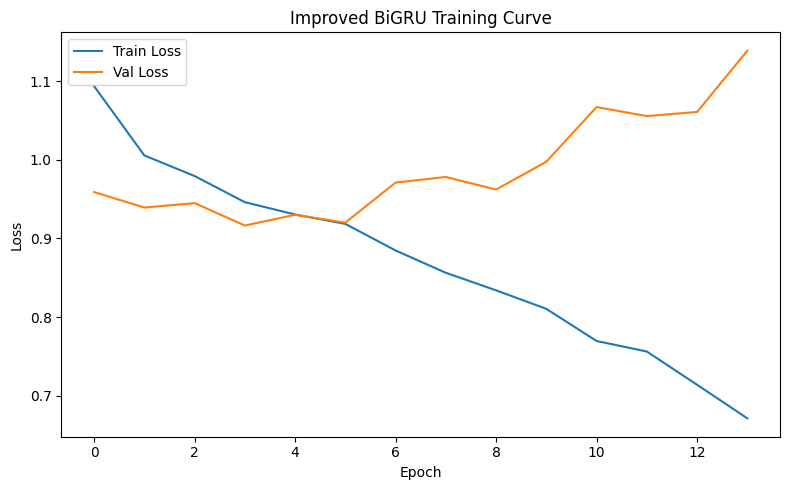

Improved model test metrics: {
  "auroc": 0.7964989517819706,
  "auprc": 0.3380670548479434,
  "accuracy": 0.6736242884250474,
  "precision": 0.19035532994923857,
  "recall": 0.75,
  "f1": 0.30364372469635625,
  "specificity": 0.6656184486373166,
  "tn": 635,
  "fp": 319,
  "fn": 25,
  "tp": 75
}


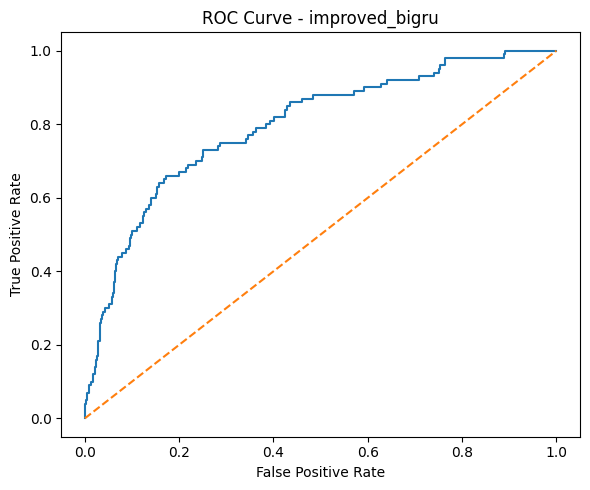

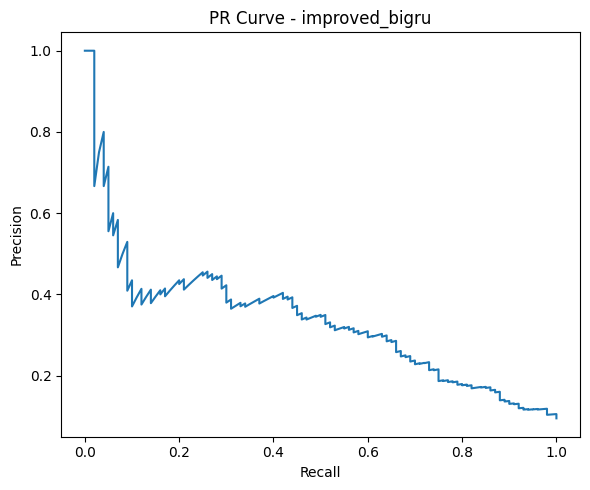

In [14]:
best_train_loader = make_loader(X_train, y_train, len_train, batch_size=best_params["batch_size"], shuffle=True)
best_val_loader = make_loader(X_val, y_val, len_val, batch_size=best_params["batch_size"], shuffle=False)
best_test_loader = make_loader(X_test, y_test, len_test, batch_size=best_params["batch_size"], shuffle=False)

improved_model = BiGRUModel(
    input_dim=len(feature_cols),
    hidden_dim=best_params["hidden_dim"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"],
).to(DEVICE)

improved_model, improved_history = fit_model(
    improved_model,
    best_train_loader,
    best_val_loader,
    train_labels=y_train,
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
    epochs=50,
    patience=10,
    model_path=MODEL_DIR / "best_bigru.pt",
)

plot_training_history(
    improved_history,
    title="Improved BiGRU Training Curve",
    save_path=OUTPUT_DIR / "training_curve_bigru.png",
)

y_true_test_gru, y_prob_test_gru = predict_proba(improved_model, best_test_loader)
improved_metrics = compute_metrics(y_true_test_gru, y_prob_test_gru)
print("Improved model test metrics:", json.dumps(improved_metrics, indent=2))
plot_roc_pr(y_true_test_gru, y_prob_test_gru, prefix="improved_bigru")

## 14. Final comparison

The purpose of this section is to bring both models together in a single summary table and visualize the final classification behaviour of the improved model.


The final comparison table answers the main question of the project: whether the improved recurrent model gives a meaningful advantage over the baseline RNN on patient-level CVD detection.

When I interpret the table, I focus on the metrics that matter most for this problem:

- whether AUROC improves,
- whether AUPRC improves,
- whether recall improves enough to justify any loss in precision or specificity,
- and whether the confusion matrix shows a more acceptable clinical error pattern.

For this kind of task, a model is not automatically better just because one number goes up. The trade-off between finding more positive cases and generating more false positives also has to be discussed.

            model     auroc     auprc  accuracy  precision  recall        f1  \
0    Baseline RNN  0.765629  0.297895  0.742884   0.214047    0.64  0.320802   
1  Improved BiGRU  0.796499  0.338067  0.673624   0.190355    0.75  0.303644   

   specificity   tn   fp  fn  tp  
0     0.753669  719  235  36  64  
1     0.665618  635  319  25  75  


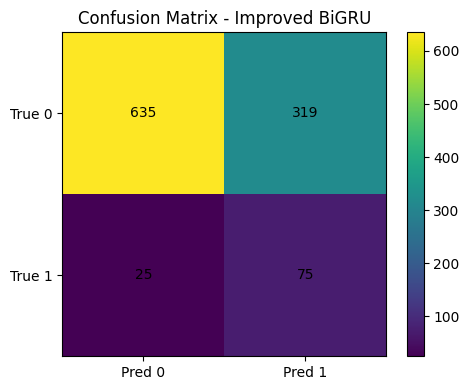

In [15]:
comparison_df = pd.DataFrame([
    {"model": "Baseline RNN", **baseline_metrics},
    {"model": "Improved BiGRU", **improved_metrics},
])
comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
print(comparison_df)

cm = confusion_matrix(y_true_test_gru, (y_prob_test_gru >= 0.5).astype(int))
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Improved BiGRU")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Pred 0", "Pred 1"])
plt.yticks(tick_marks, ["True 0", "True 1"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_bigru.png", dpi=200)
plt.show()

## 15. Discussion

This final section interprets the numerical results rather than just repeating them.

The improved BiGRU performed better than the baseline RNN on the main discrimination metrics. On the test set, AUROC increased from **0.7656** to **0.7965**, and AUPRC increased from **0.2979** to **0.3381**. Recall also improved from **0.6400** to **0.7500**, which means the improved model identified a larger share of patients in the positive class.

I consider this improvement meaningful for two reasons. First, the GRU architecture is better suited to longitudinal clinical data than a plain RNN because its gating mechanism helps control what information should be retained or updated over time. Second, the bidirectional structure summarizes the full observed five-step window more effectively, while packed sequences reduce the influence of padded timesteps.

At the same time, the improved model did not dominate the baseline on every metric. The baseline RNN had higher accuracy, precision, and specificity, so it behaved more conservatively. In other words, the BiGRU found more positive cases, but it also produced more false positives. I therefore would not claim that the BiGRU is universally superior. A more accurate interpretation is that the BiGRU achieved a better **screening-oriented** profile, whereas the baseline preserved a more conservative error pattern.

This trade-off is important in a healthcare setting. If the purpose of the model is early risk identification, higher recall and better AUPRC may be more valuable than a small gain in overall accuracy. However, if false alarms create a large downstream burden, then the drop in specificity would also matter.

There are still several limitations. This is a single-dataset study with no external validation, the imputation rules are assumption-based, and the fixed five-step window may discard useful information from longer histories. In addition, the model uses structured tabular follow-up data only and does not incorporate unstructured notes, imaging, or other sources of clinical context. For these reasons, I interpret the project as a proof-of-concept for longitudinal CVD risk modelling rather than a ready-to-deploy clinical decision support tool.

### Conclusion

Overall, the project shows that modelling the data as patient-level longitudinal sequences is useful, and that the proposed BiGRU offers a practical improvement over the baseline RNN under the same preprocessing and evaluation pipeline. The gain is strongest on AUROC, AUPRC, and recall, which makes the improved model more suitable when the main goal is to identify more patients at cardiovascular risk within the observed follow-up window.

At the same time, the results also show a cost: the improved model is less specific and less precise than the baseline. This means the model choice should depend on the clinical objective. For this assignment, I regard the BiGRU as the stronger overall model because it provides better discrimination and case-finding ability on an imbalanced clinical prediction task.